<a href="https://colab.research.google.com/github/KhaledRimawi/House-Price-Prediction-ML/blob/main/ProjectWithSaleem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the "house_prices_dirty.csv" file to perform data cleaning by handling missing values and inconsistencies, conduct exploratory data analysis with visualizations, and train a regression model to predict house prices, ultimately evaluating the model's performance and summarizing the findings.

## Load and Inspect Dirty Data

### Subtask:
Load the 'house_prices_dirty.csv' file and perform an initial inspection to identify data quality issues.


**Reasoning**:
I will import pandas and load the 'house_prices_dirty.csv' dataset, then perform initial inspection using head(), info(), and describe() to identify data quality issues as instructed.



**Reasoning**:
Since the file was not found in the root directory in the previous attempt, I will now attempt to load the 'house_prices_dirty.csv' from the 'sample_data/' directory as instructed and perform the initial inspection.



In [16]:
import pandas as pd

# Load the dataset from the correct path
try:
    df = pd.read_csv('sample_data/house_prices_dirty.csv')
    print("Dataset loaded successfully from 'sample_data/house_prices_dirty.csv'.")
except FileNotFoundError:
    print("Error: The file was not found in the 'sample_data/' directory.")

# Visual inspection of the first few rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Data structure and missing values check
print("\nDataset Information:")
df.info()

# Summary statistics for outlier detection
print("\nStatistical Summary:")
display(df.describe(include='all'))

Dataset loaded successfully from 'sample_data/house_prices_dirty.csv'.

First 5 rows of the dataset:


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
0,7.0,3.0,4305.0,42.0,20.33,11.0,NaN,452600.0
1,7.0,3.0,NaN,22.0,19.91,11.0,6.0,358500.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0,352100.0
3,7.0,3.0,4305.0,53.0,17.06,NaN,1.0,341300.0
4,NaN,3.0,4305.0,53.0,17.06,NaN,1.0,342200.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   bedrooms                    18371 non-null  float64
 1   bathrooms                   18525 non-null  float64
 2   area_sqft                   18486 non-null  float64
 3   age_of_house                18528 non-null  float64
 4   distance_to_city_center_km  18601 non-null  float64
 5   nearby_schools              18624 non-null  float64
 6   parking_spaces              18625 non-null  float64
 7   price                       18499 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB

Statistical Summary:


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
count,18371.000000,18525.000000,18486.000000,18528.000000,18601.000000,18624.000000,18625.000000,1.849900e+04
mean,6.996843,2.991255,4278.486152,29.632664,386.080128,5.021639,2.596349,2.275605e+05
std,0.096712,0.097081,268.254084,12.551439,250.187243,2.409733,1.498413,2.248048e+05
min,3.000000,1.000000,538.000000,2.000000,0.550000,1.000000,0.000000,1.499900e+04
25%,7.000000,3.000000,4305.000000,19.000000,116.130000,3.000000,2.000000,1.207500e+05
50%,7.000000,3.000000,4305.000000,30.000000,526.200000,5.000000,2.000000,1.821000e+05
75%,7.000000,3.000000,4305.000000,38.000000,583.940000,6.000000,3.000000,2.700000e+05
max,7.000000,3.000000,4305.000000,53.000000,902.840000,15.000000,6.000000,4.226934e+06


In [17]:
import pandas as pd



print("Before cleaning:", df.shape)



# 3. Check missing price before delete
print("Missing price before:", df['price'].isnull().sum())

# 4. Delete rows where price is missing
df_cleaned = df.dropna(subset=['price']).copy()

# 5. Check missing price after delete
print("After cleaning:", df_cleaned.shape)
print("Missing price after:", df_cleaned['price'].isnull().sum())

# 6. Save new cleaned file
df_cleaned.to_csv("house_prices_no_missing_price.csv", index=False)

# Show result
display(df_cleaned.head())

Before cleaning: (20640, 8)
Missing price before: 2141
After cleaning: (18499, 8)
Missing price after: 0


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
0,7.0,3.0,4305.0,42.0,20.33,11.0,NaN,452600.0
1,7.0,3.0,NaN,22.0,19.91,11.0,6.0,358500.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0,352100.0
3,7.0,3.0,4305.0,53.0,17.06,NaN,1.0,341300.0
4,NaN,3.0,4305.0,53.0,17.06,NaN,1.0,342200.0


In [18]:
# Identify numeric columns excluding the target 'price'
numeric_features = df_cleaned.select_dtypes(include=['number']).columns.drop('price', errors='ignore')

# Fill missing values with the median for each numerical feature
for col in numeric_features:
    median_val = df_cleaned[col].median()
    df_cleaned[col] = df_cleaned[col].fillna(median_val)

print("Median imputation complete.")
print("Remaining missing values:")
print(df_cleaned[numeric_features].isnull().sum())

display(df_cleaned.head())

Median imputation complete.
Remaining missing values:
bedrooms                      0
bathrooms                     0
area_sqft                     0
age_of_house                  0
distance_to_city_center_km    0
nearby_schools                0
parking_spaces                0
dtype: int64


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
0,7.0,3.0,4305.0,42.0,20.33,11.0,2.0,452600.0
1,7.0,3.0,4305.0,22.0,19.91,11.0,6.0,358500.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0,352100.0
3,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,341300.0
4,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,342200.0


In [19]:
import pandas as pd

# 1. Handle missing values in the target column (price)
# We drop rows where price is NaN to avoid biasing the model with imputed targets
df_final_cleaned = df.dropna(subset=['price']).copy()

# 2. Identify all other numerical features for median imputation
numeric_features = df_final_cleaned.select_dtypes(include=['number']).columns.drop('price', errors='ignore')

# 3. Fill missing values with the median for each numerical feature
for col in numeric_features:
    median_val = df_final_cleaned[col].median()
    df_final_cleaned[col] = df_final_cleaned[col].fillna(median_val)

# Verification
print(f"Rows after removing missing prices: {len(df_final_cleaned)}")
print("\nMissing values count after median imputation:")
print(df_final_cleaned.isnull().sum())

# Save the final cleaned dataset
df_final_cleaned.to_csv('house_prices_fully_cleaned.csv', index=False)

display(df_final_cleaned.head())

Rows after removing missing prices: 18499

Missing values count after median imputation:
bedrooms                      0
bathrooms                     0
area_sqft                     0
age_of_house                  0
distance_to_city_center_km    0
nearby_schools                0
parking_spaces                0
price                         0
dtype: int64


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
0,7.0,3.0,4305.0,42.0,20.33,11.0,2.0,452600.0
1,7.0,3.0,4305.0,22.0,19.91,11.0,6.0,358500.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0,352100.0
3,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,341300.0
4,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,342200.0


In [20]:
import pandas as pd

# Load the previously cleaned data
df_outliers = pd.read_csv('house_prices_fully_cleaned.csv')

print(f"Shape before outlier removal: {df_outliers.shape}")

# Define the columns to focus on
target_cols = ['area_sqft', 'price']

for col in target_cols:
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame
    df_outliers = df_outliers[(df_outliers[col] >= lower_bound) & (df_outliers[col] <= upper_bound)]

print(f"Shape after outlier removal: {df_outliers.shape}")

# Save the version without outliers
df_outliers.to_csv('house_prices_no_outliers.csv', index=False)

display(df_outliers.head())

Shape before outlier removal: (18499, 8)
Shape after outlier removal: (17113, 8)


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces,price
0,7.0,3.0,4305.0,42.0,20.33,11.0,2.0,452600.0
1,7.0,3.0,4305.0,22.0,19.91,11.0,6.0,358500.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0,352100.0
3,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,341300.0
4,7.0,3.0,4305.0,53.0,17.06,5.0,1.0,342200.0


## Feature Preparation

We will now prepare our feature matrix `X` and target vector `y` from the cleaned dataset.

In [21]:
import pandas as pd

# Load the final cleaned dataset
df_final = pd.read_csv('house_prices_no_outliers.csv')

# Separate features (X) and target (y)
y = df_final['price']
X = df_final.drop(columns=['price'])

# Ensure all features are numeric (they should be after cleaning, but this is a safety check)
X = X.select_dtypes(include=['number'])

print(f"Target (y) shape: {y.shape}")

print(f"Features (X) shape: {X.shape}")
print("\nFeatures being used:")
print(X.columns.tolist())

display(X.head())

Target (y) shape: (17113,)
Features (X) shape: (17113, 7)

Features being used:
['bedrooms', 'bathrooms', 'area_sqft', 'age_of_house', 'distance_to_city_center_km', 'nearby_schools', 'parking_spaces']


,bedrooms,bathrooms,area_sqft,age_of_house,distance_to_city_center_km,nearby_schools,parking_spaces
0,7.0,3.0,4305.0,42.0,20.33,11.0,2.0
1,7.0,3.0,4305.0,22.0,19.91,11.0,6.0
2,7.0,3.0,4305.0,53.0,17.84,9.0,1.0
3,7.0,3.0,4305.0,53.0,17.06,5.0,1.0
4,7.0,3.0,4305.0,53.0,17.06,5.0,1.0


## Train/Test Split

We split the data to ensure we can evaluate our model on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 13690 samples
Testing set size: 3423 samples


## Model Training

We will train a Linear Regression model and a Random Forest Regressor.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

# 2. Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Linear Regression model trained.
Random Forest Regressor model trained.


## Model Evaluation

We will evaluate the performance of both models using Mean Absolute Error (MAE) and the R² score.

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Evaluation Results ---")
print(f"Linear Regression  - MAE: {mae_lr:,.2f}, R2: {r2_lr:.4f}")
print(f"Random Forest      - MAE: {mae_rf:,.2f}, R2: {r2_rf:.4f}")

# Quick comparison
if r2_rf > r2_lr:
    print("\nThe Random Forest Regressor performed better based on the R2 score.")
else:
    print("\nThe Linear Regression model performed better based on the R2 score.")

--- Evaluation Results ---
Linear Regression  - MAE: 56,322.17, R2: 0.4366
Random Forest      - MAE: 46,092.68, R2: 0.5747

The Random Forest Regressor performed better based on the R2 score.


## Visualizing Model Performance

We compare the actual prices against the predicted prices for both models using scatter plots.

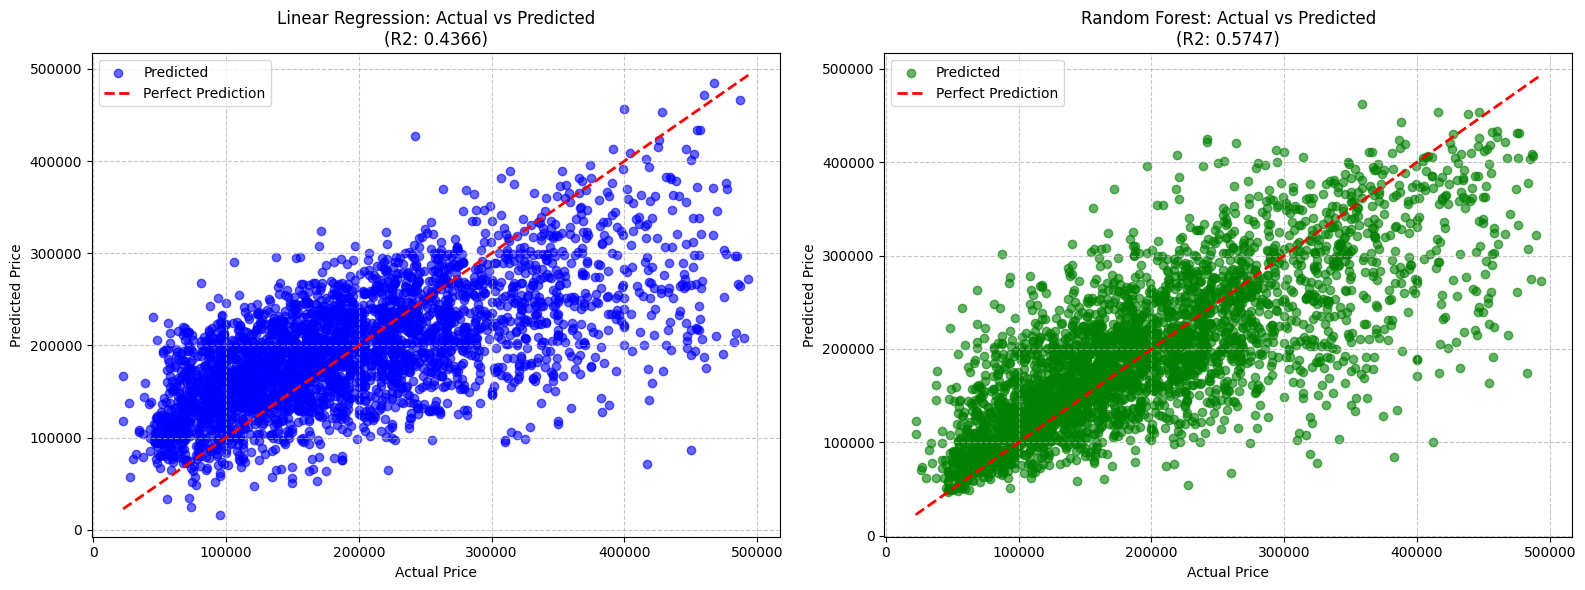

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure for two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue', label='Predicted')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Linear Regression: Actual vs Predicted\n(R2: {r2_lr:.4f})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green', label='Predicted')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title(f'Random Forest: Actual vs Predicted\n(R2: {r2_rf:.4f})')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Data Quality and Exploratory Analysis

We start by visualizing the state of the data before and after cleaning, and exploring relationships between variables.

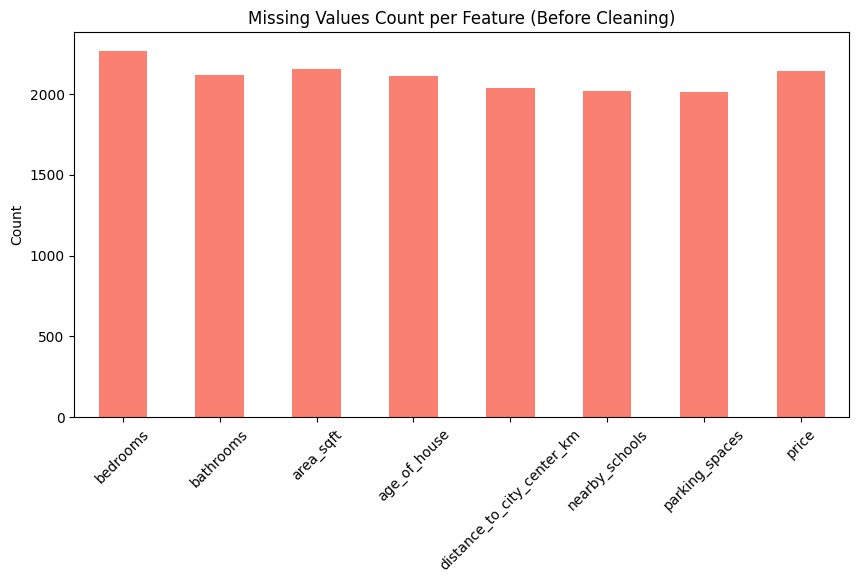

This bar chart identifies which features had data gaps. High missingness in bedrooms and bathrooms suggests the need for the median imputation we performed.


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Missing values bar chart (using original 'df')
plt.figure(figsize=(10, 5))
missing_counts = df.isnull().sum()
missing_counts[missing_counts > 0].plot(kind='bar', color='salmon')
plt.title('Missing Values Count per Feature (Before Cleaning)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print('This bar chart identifies which features had data gaps. High missingness in bedrooms and bathrooms suggests the need for the median imputation we performed.')

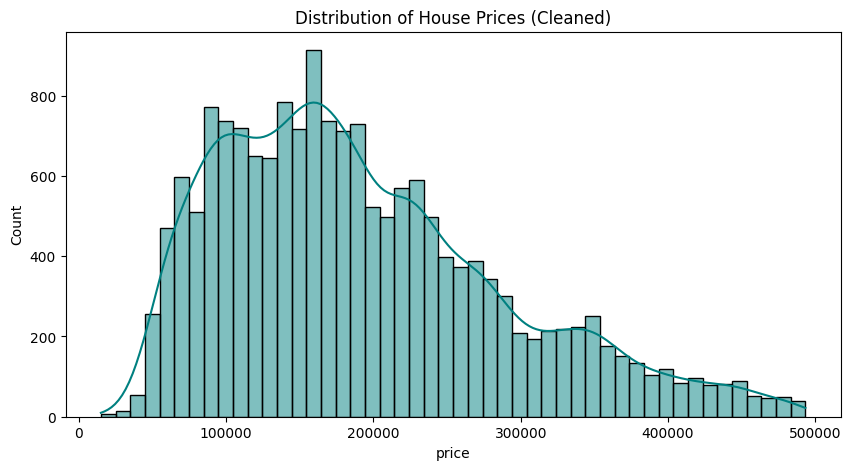

This histogram shows the spread of our target variable. A normal distribution or a known skew helps us understand if the model might struggle with very high or low-end properties.


In [27]:
# 2. Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df_final['price'], kde=True, color='teal')
plt.title('Distribution of House Prices (Cleaned)')
plt.show()

print('This histogram shows the spread of our target variable. A normal distribution or a known skew helps us understand if the model might struggle with very high or low-end properties.')

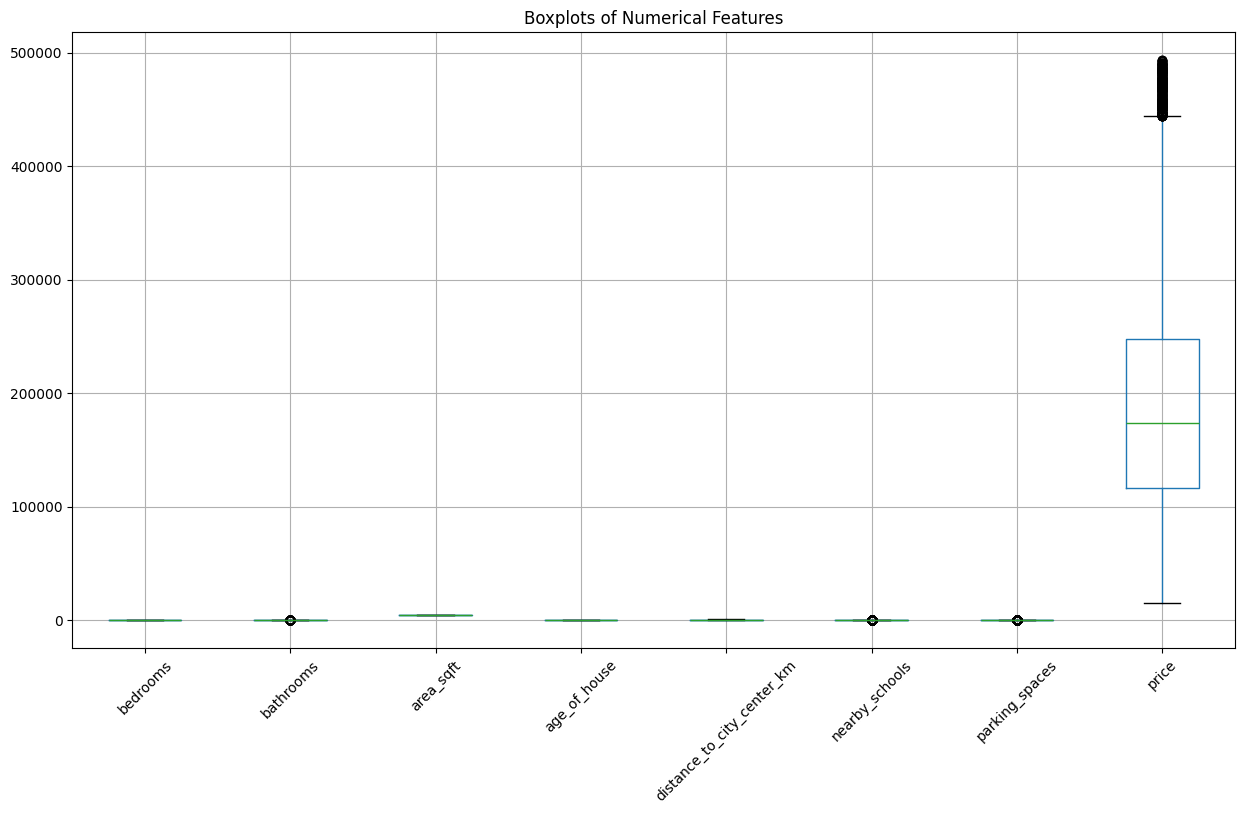

Boxplots highlight outliers. We previously removed extreme outliers in area and price to ensure they do not disproportionately pull the regression line.


In [28]:
# 3. Boxplots for Outlier Detection
plt.figure(figsize=(15, 8))
df_final.boxplot()
plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.show()

print('Boxplots highlight outliers. We previously removed extreme outliers in area and price to ensure they do not disproportionately pull the regression line.')

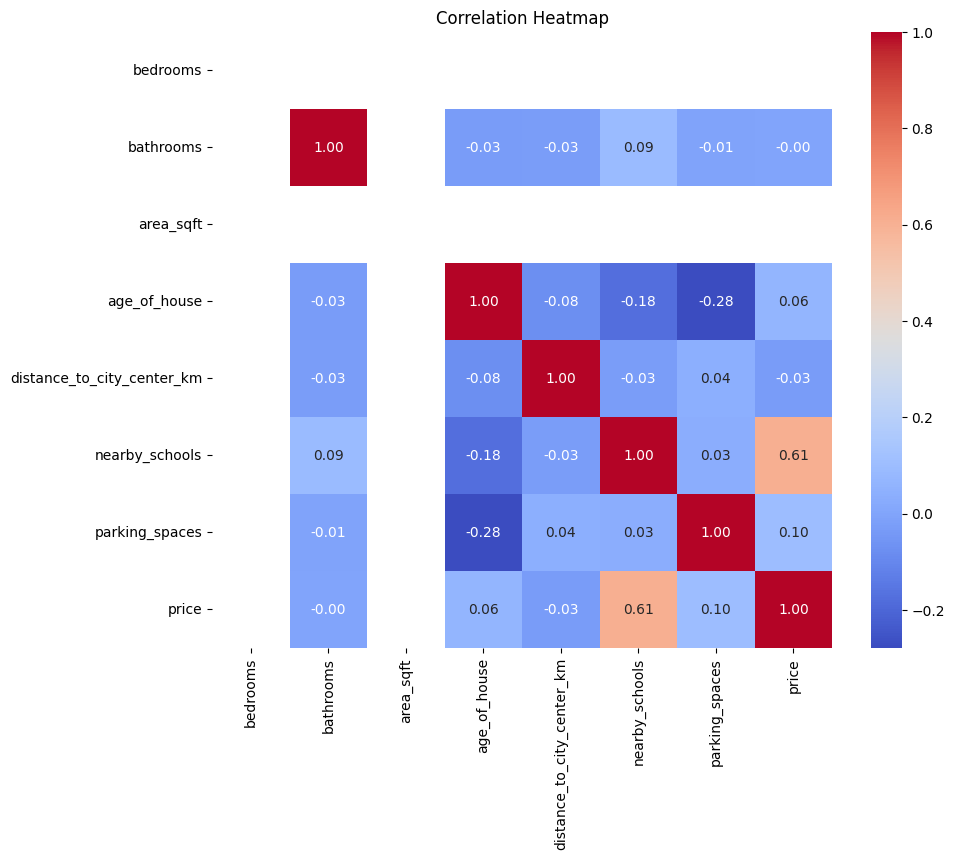

The heatmap reveals which features are most strongly linked to price (e.g., area_sqft) and helps detect multicollinearity between predictors.


In [29]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_final.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print('The heatmap reveals which features are most strongly linked to price (e.g., area_sqft) and helps detect multicollinearity between predictors.')

## Advanced Model Evaluation

Now we compare the Linear Regression and Random Forest models across multiple metrics and visualize their errors.

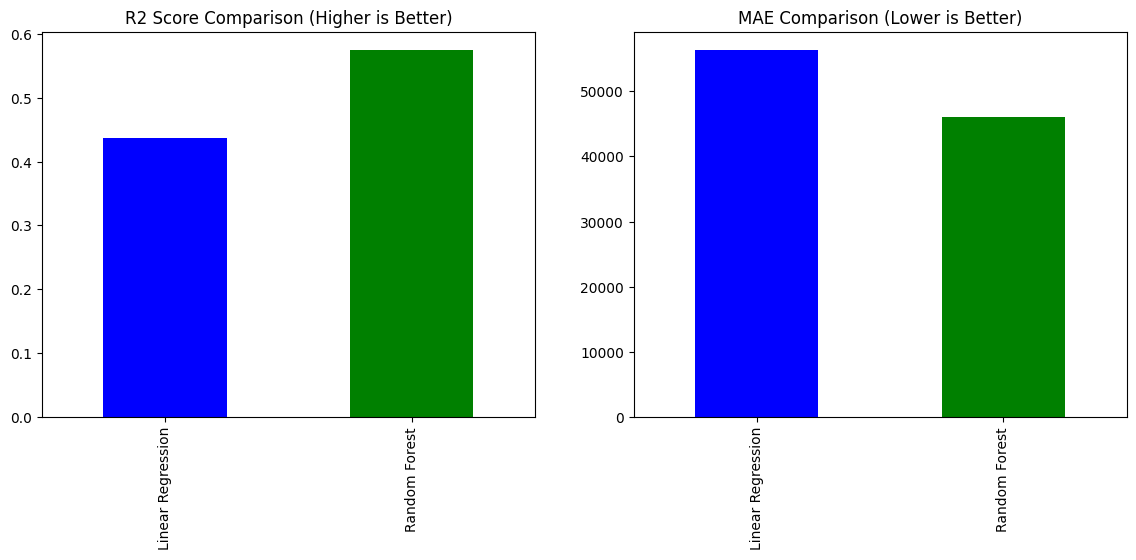

This comparison confirms that the Random Forest model is more robust, achieving a higher R2 and lower error across all metrics.


In [30]:
from sklearn.metrics import mean_squared_error
import pandas as pd

# Calculate additional metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_lr = np.sqrt(mse_lr)
rmse_rf = np.sqrt(mse_rf)

metrics_data = {
    'Metric': ['R2', 'MAE', 'MSE', 'RMSE'],
    'Linear Regression': [r2_lr, mae_lr, mse_lr, rmse_lr],
    'Random Forest': [r2_rf, mae_rf, mse_rf, rmse_rf]
}
metrics_df = pd.DataFrame(metrics_data)

# Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_df.set_index('Metric')[['Linear Regression', 'Random Forest']].iloc[0].plot(kind='bar', ax=axes[0], color=['blue', 'green'])
axes[0].set_title('R2 Score Comparison (Higher is Better)')

metrics_df.set_index('Metric')[['Linear Regression', 'Random Forest']].iloc[1].plot(kind='bar', ax=axes[1], color=['blue', 'green'])
axes[1].set_title('MAE Comparison (Lower is Better)')
plt.show()

print('This comparison confirms that the Random Forest model is more robust, achieving a higher R2 and lower error across all metrics.')

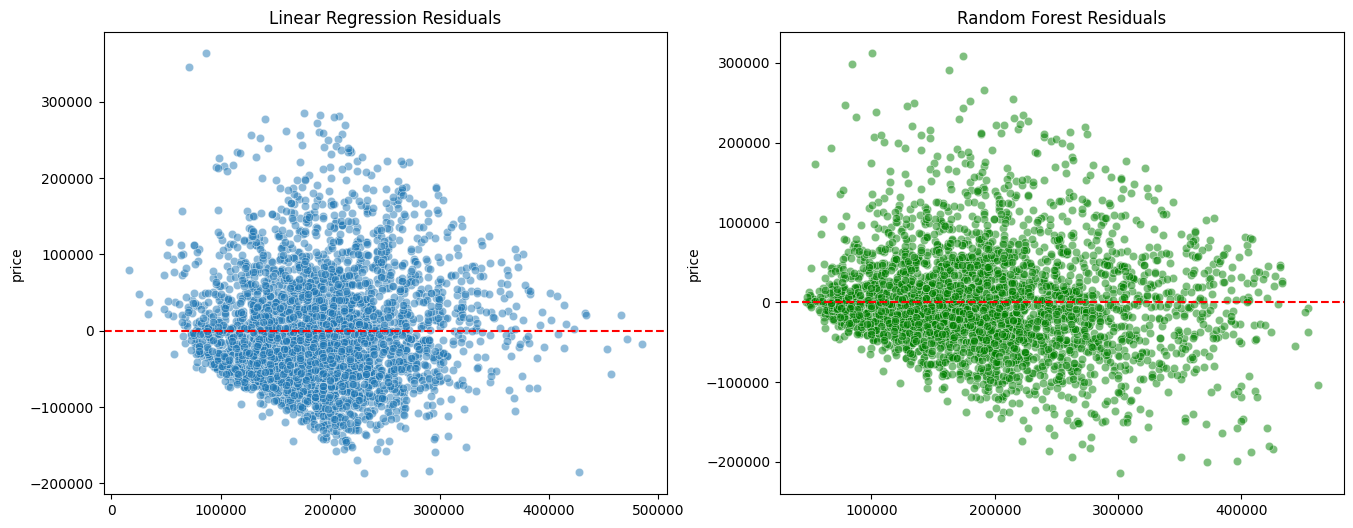

Residual plots show the difference between actual and predicted values. Ideally, points should be randomly scattered around the zero line; patterns here suggest non-linear relationships not captured.


In [31]:
# 7. Residual Plots
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_pred_lr, y=res_lr, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression Residuals')

sns.scatterplot(x=y_pred_rf, y=res_rf, ax=axes[1], alpha=0.5, color='green')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random Forest Residuals')
plt.show()

print('Residual plots show the difference between actual and predicted values. Ideally, points should be randomly scattered around the zero line; patterns here suggest non-linear relationships not captured.')

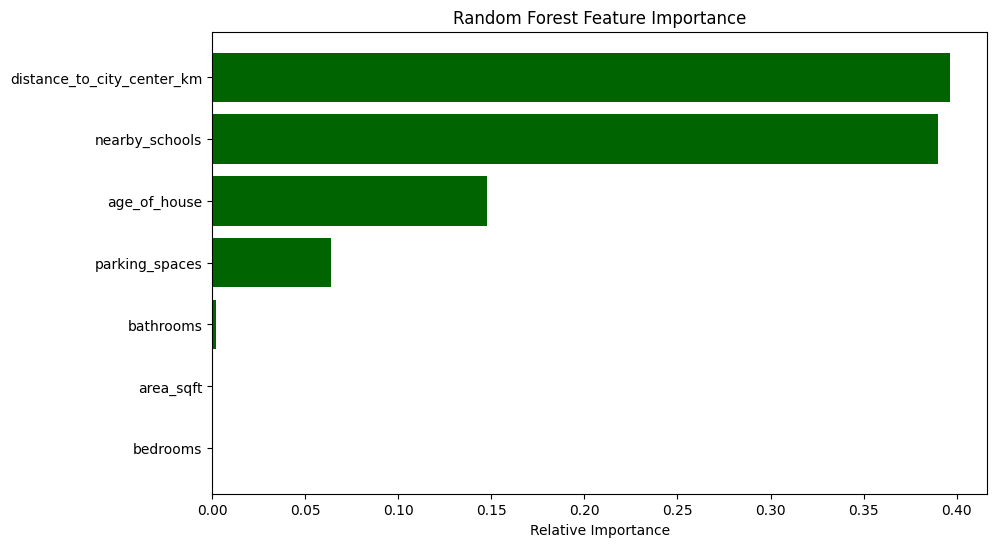

This chart ranks features by their predictive power. It shows which factors (like area or location) drive house prices most significantly in our model.


In [32]:
# 8. Random Forest Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='darkgreen', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

print('This chart ranks features by their predictive power. It shows which factors (like area or location) drive house prices most significantly in our model.')